# 04: Relational EDA on Engineered Features

In this notebook, we perform **relational exploratory data analysis (EDA)** on
the post-feature-engineering dataset for the USA real estate project.

We focus on:

- Understanding how engineered features relate to the target **`price`**.
- Quantifying linear and monotonic correlations using **Pearson** and
  **Spearman** correlation coefficients.
- Visualising bivariate relationships for key engineered features such as
  `house_size`, `total_rooms`, `acre_lot_log1p`, `bath_log1p`,
  `city_listing_count`, and `state_listing_count`.
- Examining the impact of binary indicators such as `status_is_sold` and
  `status_is_ready_to_build`, as well as a decoded `status_decoded`
  categorical feature.

The goal is to extract modelling-relevant insights in a way that is
reproducible and ready to feed into the subsequent regression modelling
pipeline.


In [3]:
"""Global configuration and imports for the DOAA CA1 EDA notebook.

This module centralises shared constants (for example, the target column name,
random seed, plotting limits, and expected engineered features) to ensure
consistent and reproducible analysis across notebooks and scripts.

Attributes:
    TARGET_COL: Name of the regression target column.
    RANDOM_STATE: Seed used for all pseudo-random operations.
    MAX_ROWS_PAIRPLOT: Maximum number of rows to sample for pair plots.
    MAX_POINTS_SCATTER: Maximum number of points to display in scatter plots.
    EXPECTED_KEY_FEATURES: List of engineered feature names expected to be
        present after feature engineering.
"""

from typing import Dict, List

import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import drive  # type: ignore
from pathlib import Path
from matplotlib import pyplot as plt
from pandas.io.formats.style import Styler
from scipy import stats

# ---- Drive mount (Colab) ----
drive.mount("/content/drive")

# Set plotting style for Seaborn.
sns.set(style="whitegrid")

# Global configuration constants.
TARGET_COL = "price"
RANDOM_STATE = 42
MAX_ROWS_PAIRPLOT = 50_000
MAX_POINTS_SCATTER = 80_000

# Engineered features expected to be present after feature engineering.
EXPECTED_KEY_FEATURES = [
    "house_size",
    "total_rooms",
    "acre_lot_log1p",
    "bath_log1p",
    "city_listing_count",
    "state_listing_count",
    "status_is_ready_to_build",
    "status_is_sold",
]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


The configuration above sets up core libraries, plotting defaults, and a list
of expected engineered features. The notebook is written defensively: if some
features are missing, the code will skip them rather than fail, keeping the
EDA robust to upstream changes in the feature engineering pipeline.

---
# 2. Load Engineered Dataset

We now load the **feature-engineered dataset** from CSV. This dataset is
expected to contain:

- `price` as the cleaned regression target, with missing values already
  handled in the data cleaning stage.
- Engineered numeric features such as `house_size`, `total_rooms`,
  `acre_lot_log1p`, and `bath_log1p`.
- Engineered indicator and count features such as `status_is_sold`,
  `status_is_ready_to_build`, `city_listing_count`, and `state_listing_count`.

We first load the data and perform a quick structural check.

In [4]:
"""Load the engineered DOAA dataset from CSV.

This module reads the pre-processed dataset stored in Google Drive and performs
a basic validation check to ensure that the regression target column is present.
The loaded dataset is used for downstream exploratory data analysis (EDA),
statistical testing, and modelling tasks.

Attributes:
    ENGINEERED_CSV_PATH: Absolute filepath pointing to the engineered dataset.
"""

# ---------------------------------------------------------------------------
# Filepath configuration
# ---------------------------------------------------------------------------
ENGINEERED_CSV_PATH: str = (
    "/content/drive/MyDrive/Colab Notebooks/DOAA/"
    "data_processed/final_dataset_20251116_0720.csv"
)

# ---------------------------------------------------------------------------
# Load dataset
# ---------------------------------------------------------------------------
def load_engineered_dataset(csv_path: str, target_col: str) -> pd.DataFrame:
    """Load the engineered dataset and validate the target column.

    Args:
        csv_path: Absolute path to the engineered dataset CSV file.
        target_col: Name of the regression target column.

    Returns:
        A pandas DataFrame containing the fully engineered dataset.

    Raises:
        FileNotFoundError: If the CSV file cannot be located.
        KeyError: If the target column is missing from the dataset.
    """
    path = Path(csv_path)

    if not path.exists():
        raise FileNotFoundError(
            f"Engineered dataset not found at: {csv_path!r}"
        )

    df_loaded = pd.read_csv(path)

    if target_col not in df_loaded.columns:
        raise KeyError(
            f"Target column '{target_col}' not found in engineered dataset. "
            f"Columns available: {list(df_loaded.columns)}"
        )

    print(
        f"Engineered dataset successfully loaded. "
        f"Shape: {df_loaded.shape}"
    )

    return df_loaded


# ---------------------------------------------------------------------------
# Execute load step
# ---------------------------------------------------------------------------
df_rel = load_engineered_dataset(
    csv_path=ENGINEERED_CSV_PATH,
    target_col=TARGET_COL,
)

df_rel.head()

Engineered dataset successfully loaded. Shape: (2224841, 9)


,acre_lot_log1p,bath_log1p,city_listing_count,house_size,state_listing_count,status_is_ready_to_build,status_is_sold,total_rooms,price
0,0.113329,1.098612,2,920.0,3126,0,0,5,105000.0
1,0.076961,1.098612,2,1527.0,3126,0,0,6,80000.0
2,0.139762,0.693147,17,748.0,3126,0,0,3,67000.0
3,0.095310,1.098612,81,1800.0,3126,0,0,6,145000.0
4,0.048790,1.098612,64,2514.0,3126,0,0,8,65000.0


The preview above confirms that the engineered dataset has been loaded and
that the `price` column is available as the modelling target. In the next
step, we reconstruct a human-readable property status from the one-hot encoded
status flags to make subsequent visualisations more interpretable.

---
# 3. Rebuild `status_decoded` from One-Hot Flags

The upstream feature engineering pipeline created one-hot encoded status
features such as:

- `status_is_sold`
- `status_is_ready_to_build`

To make the analysis more interpretable, we reconstruct a single
`status_decoded` categorical column using the following rule set:

- If `status_is_sold == 1` → `"sold"`
- Else if `status_is_ready_to_build == 1` → `"ready_to_build"`
- Else (both 0 or missing) → `"ready_to_build"` (treated as default)

This allows us to examine price behaviour across intuitive status categories.

In [5]:
"""Rebuild a human-readable property status column.

This module reconstructs a categorical `status_decoded` column from the
engineered one-hot encoded status flags. This is essential for downstream
EDA and interpretability, ensuring that business rules related to property
status are transparently reflected in the dataset.

Business Logic:
    - If ``status_is_sold == 1``               → "sold"
    - If ``status_is_ready_to_build == 1``     → "ready_to_build"
    - If both flags are 0 or missing           → "ready_to_build" (default)

Returns a new DataFrame with an added `status_decoded` column.
"""


def add_decoded_status_column(df: pd.DataFrame) -> pd.DataFrame:
    """Add a decoded categorical status column from one-hot flags.

    Args:
        df: Engineered dataset containing the one-hot encoded status columns.

    Returns:
        A pandas DataFrame with an added ``status_decoded`` column that
        reflects the business rules for interpreting property status.

    Raises:
        KeyError: If required one-hot columns are missing.
    """
    required_cols = ["status_is_sold", "status_is_ready_to_build"]

    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise KeyError(
            "Missing required one-hot status columns: "
            f"{missing}. Cannot decode property status."
        )

    df_out = df.copy()

    sold_flag = df_out["status_is_sold"].fillna(0).astype(int)
    ready_flag = df_out["status_is_ready_to_build"].fillna(0).astype(int)

    df_out["status_decoded"] = np.select(
        condlist=[sold_flag == 1, ready_flag == 1],
        choicelist=["sold", "ready_to_build"],
        default="ready_to_build",
    ).astype("object")

    return df_out


# Apply decoding
df_rel = add_decoded_status_column(df_rel)

df_rel[
    ["status_is_sold", "status_is_ready_to_build", "status_decoded"]
].head()

,status_is_sold,status_is_ready_to_build,status_decoded
0,0,0,ready_to_build
1,0,0,ready_to_build
2,0,0,ready_to_build
3,0,0,ready_to_build
4,0,0,ready_to_build


The preview confirms that `status_decoded` has been added based on the
underlying one-hot flags. This derived feature will be used as a categorical
variable in subsequent relational analyses.

---
# 4. Helper Functions for Typing and Table Styling

To keep the notebook organised, we define helper functions to:

- Identify **numeric**, **binary**, and **categorical** columns.
- Summarise the structure of the dataset (dtypes, uniqueness, missingness).
- Apply simple styling to tabular outputs to make them easier to read.

These utilities will be reused across the rest of the notebook.

In [6]:
"""Helper utilities for typing, column detection, and styled tables.

This module provides convenience functions to:
    * Identify numeric, binary, and categorical columns.
    * Summarise dataset structure (dtypes, uniqueness, missingness).
    * Apply lightweight styling for tabular summaries in notebooks.
"""


def get_numeric_columns(
    df: pd.DataFrame,
    exclude: List[str] | None = None,
) -> List[str]:
    """Return numeric column names, optionally excluding specific columns.

    Args:
        df: Input dataset.
        exclude: Optional list of columns to exclude from the result.

    Returns:
        A list of column names whose dtypes are numeric and not in `exclude`.
    """
    exclude = exclude or []
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    return [col for col in numeric_cols if col not in exclude]


def get_binary_columns(
    df: pd.DataFrame,
    exclude: List[str] | None = None,
) -> List[str]:
    """Return names of binary indicator columns (0/1 or True/False).

    A column is considered binary if, after dropping missing values, it
    contains exactly two unique values, and those values are a subset of
    {0, 1} or {True, False}.

    Args:
        df: Input dataset.
        exclude: Optional list of columns to exclude from the result.

    Returns:
        A list of column names that behave as binary indicators.
    """
    exclude_set = set(exclude or [])
    binary_cols: List[str] = []

    for col in df.columns:
        if col in exclude_set:
            continue

        series = df[col]
        non_null = series.dropna()

        if non_null.nunique() != 2:
            continue

        unique_vals = set(non_null.unique().tolist())
        if unique_vals.issubset({0, 1}) or unique_vals.issubset(
            {True, False}
        ):
            binary_cols.append(col)

    return binary_cols


def get_categorical_columns(
    df: pd.DataFrame,
    numeric_cols: List[str],
    binary_cols: List[str],
) -> List[str]:
    """Return non-numeric, non-binary categorical column names.

    Args:
        df: Input dataset.
        numeric_cols: List of numeric column names.
        binary_cols: List of binary column names.

    Returns:
        A list of column names treated as categorical (neither numeric nor
        binary, based on dtype and provided lists).
    """
    excluded = set(numeric_cols).union(set(binary_cols))
    categorical_cols = [
        col
        for col in df.columns
        if col not in excluded
        and not np.issubdtype(df[col].dtype, np.number)
    ]
    return categorical_cols


def summarize_structure(df: pd.DataFrame) -> pd.DataFrame:
    """Summarise dtypes, uniqueness, and missingness for each column.

    The output is designed as a quick structural overview of the dataset,
    capturing:
        * Data type
        * Number of unique values (excluding NaNs)
        * Number of missing values
        * Percentage of missing values

    Args:
        df: Input dataset.

    Returns:
        A DataFrame with columns: ['dtype', 'n_unique', 'n_missing',
        'pct_missing'], sorted by descending percentage of missing values.
    """
    summary = pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "n_unique": df.nunique(dropna=True),
            "n_missing": df.isna().sum(),
        }
    )

    if len(df) > 0:
        summary["pct_missing"] = summary["n_missing"] / len(df) * 100.0
    else:
        summary["pct_missing"] = 0.0

    return summary.sort_values("pct_missing", ascending=False)


def style_generic_table(df: pd.DataFrame) -> Styler:
    """Apply simple styling to a descriptive table.

    This function is intended for use in notebooks to enhance readability
    of summary tables using basic HTML and CSS styling.

    Args:
        df: Input summary DataFrame.

    Returns:
        A pandas Styler object with table attributes, borders, and
        contrasting colours applied.
    """
    return (
        df.style.set_table_attributes('class="table table-sm table-striped"')
        .set_properties(
            **{
                "border": "1px solid #ccc",
                "font-size": "12px",
                "padding": "4px 6px",
            }
        )
        .set_table_styles(
            [
                {
                    "selector": "th",
                    "props": (
                        "background-color: #333333; "
                        "color: white;"
                    ),
                },
                {
                    "selector": "td",
                    "props": (
                        "background-color: #111111; "
                        "color: #f3f3f3;"
                    ),
                },
            ]
        )
    )


# ---------------------------------------------------------------------------
# Column typing summary for the engineered dataset
# ---------------------------------------------------------------------------
numeric_cols = get_numeric_columns(df_rel, exclude=[TARGET_COL])
binary_cols = get_binary_columns(
    df_rel,
    exclude=[TARGET_COL, "status_decoded"],
)
categorical_cols = get_categorical_columns(
    df_rel,
    numeric_cols=numeric_cols,
    binary_cols=binary_cols,
)

structure_summary = summarize_structure(df_rel)

print("Numeric columns:", numeric_cols)
print("Binary columns:", binary_cols)
print("Categorical columns:", categorical_cols)

display(style_generic_table(structure_summary.head(25)))

Numeric columns: ['acre_lot_log1p', 'bath_log1p', 'city_listing_count', 'house_size', 'state_listing_count', 'status_is_ready_to_build', 'status_is_sold', 'total_rooms']
Binary columns: ['status_is_ready_to_build', 'status_is_sold']
Categorical columns: ['status_decoded']


,dtype,n_unique,n_missing,pct_missing
acre_lot_log1p,float64,11835,0,0.000000
bath_log1p,float64,4,0,0.000000
city_listing_count,int64,1133,0,0.000000
house_size,float64,17932,0,0.000000
state_listing_count,int64,56,0,0.000000
status_is_ready_to_build,int64,2,0,0.000000
status_is_sold,int64,2,0,0.000000
total_rooms,int64,8,0,0.000000
price,float64,90425,0,0.000000
status_decoded,object,2,0,0.000000


The summary above provides an at-a-glance view of the dataset:

- **Numeric columns** include core engineered features such as
  `house_size`, `total_rooms`, `acre_lot_log1p`, `bath_log1p`,
  `city_listing_count`, and `state_listing_count`.
- **Binary columns** capture indicator-style features such as
  `status_is_sold` and `status_is_ready_to_build`.
- **Categorical columns** include fields like the decoded `status_decoded`.

This structural overview guides which features are treated as continuous,
discrete, or categorical in the relational EDA that follows.

---
# 5. Target Variable: Distribution and Summary

Before examining relationships with other features, we revisit the target
variable `price`.

We compute descriptive statistics and visualise the distribution using a
histogram and boxplot. This helps us understand the overall scale, spread,
skewness, and presence of extreme values, all of which are important for
interpreting correlations and modelling decisions.

,price
count,2224841.000000
mean,403363.905484
std,314687.126622
min,0.000000
1%,10000.000000
25%,165000.000000
50%,325000.000000
75%,550000.000000
99%,1127500.000000
max,1127500.000000


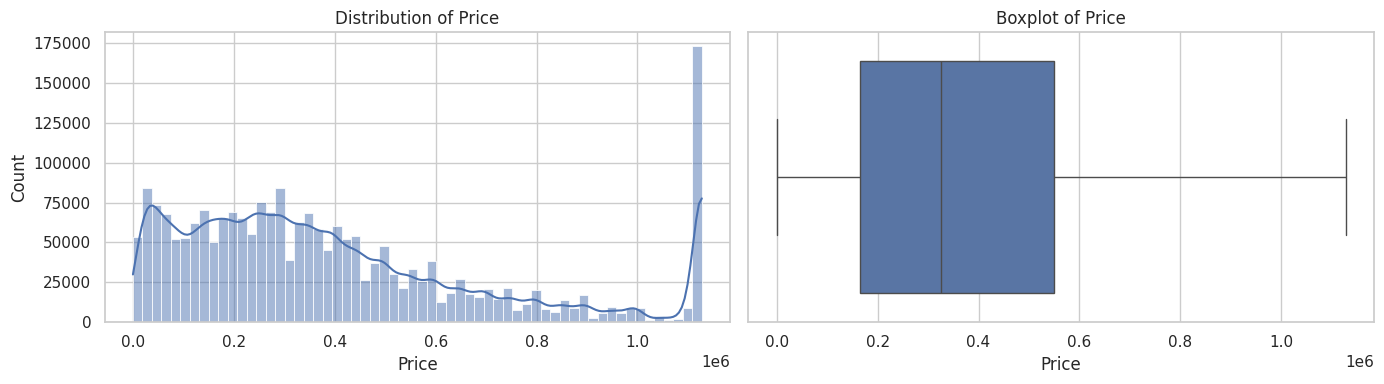

In [7]:
"""Target variable summary and visualisation utilities.

This module provides a concise descriptive summary of the target feature
(e.g., property price) and visualises its distribution using a histogram
and boxplot. These diagnostics support early assessment of skewness,
outliers, and modelling considerations.
"""


def describe_target(series: pd.Series) -> pd.DataFrame:
    """Generate a descriptive summary for the target variable.

    The summary includes standard descriptive statistics (mean, median,
    variance-related measures) and selected percentiles useful for
    understanding skewness or heavy-tailed behaviour.

    Args:
        series: A pandas Series representing the regression target.

    Returns:
        A DataFrame containing descriptive statistics for the target.
    """
    desc = series.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])
    return desc.to_frame(name=TARGET_COL)


# ---------------------------------------------------------------------------
# Summaries and diagnostic plots
# ---------------------------------------------------------------------------
price_series = pd.to_numeric(df_rel[TARGET_COL], errors="coerce")

display(style_generic_table(describe_target(price_series)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(
    price_series.dropna(),
    bins=60,
    kde=True,
    ax=axes[0],
)
axes[0].set_title("Distribution of Price")
axes[0].set_xlabel("Price")

sns.boxplot(
    x=price_series.dropna(),
    ax=axes[1],
)
axes[1].set_title("Boxplot of Price")
axes[1].set_xlabel("Price")

plt.tight_layout()
plt.show()

With reference to the distribution and boxplot above, the Price feature displays a highly right-skewed distribution, suggesting that most homes transact within a moderate range while a noticeable subset extends into significantly higher values. This creates a long tail of premium or atypical listings. The observations are structured below:

**Strong Right Skewness**
- The majority of listings fall between approximately $100k-$500k.

- A long right tail indicates the presence of a smaller but impactful segment of high-priced properties.

**Sharp Spike Near $1.1M**

- Potential capped values or standardised high-end entries or the existence of a large quantity of similarly priced luxury units.

**High Variability in Typical Transactions**
- The boxplot shows a wide interquartile range (IQR), signalling considerable variation among regular-priced homes.

- The upper whisker stretches substantially beyond the median, emphasising the spread.

Overall, the Price feature demonstrates pronounced skewness, broad dispersion, and a dense cluster of upper-end values. These characteristics highlight the importance of applying appropriate transformations and performing targeted outlier checks to enhance the reliability of downstream modelling.

---
# 6. Correlation Analysis: Engineered Numeric Features vs Price

We now quantify the association between each **numeric engineered feature** and
`price` using both:

1. **Pearson correlation** – measures linear association.
2. **Spearman correlation** – measures monotonic association based on ranks.

For vectors \( x \) (feature) and \( y \) (price), the Pearson correlation
coefficient \( r \) is:

$$
r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}
         {\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2}
          \sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}
$$

The Spearman correlation applies the same formula to the ranked values of
\( x_i \) and \( y_i \). We also compute two-sided p-values to assess the
likelihood that the observed correlations arose by chance.

In [8]:
"""Correlation computation utilities for numeric features.

This section provides helper functions to:
    * Compute Pearson and Spearman correlations between numeric features
      and the target variable.
    * Generate a styled correlation summary table with visual gradients.
"""


def compute_target_correlations(
    df: pd.DataFrame,
    target_col: str,
    feature_cols: List[str],
) -> pd.DataFrame:
    """Compute Pearson and Spearman correlations versus the target.

    For each feature in ``feature_cols``, this function:
        * Coerces both feature and target to numeric.
        * Drops rows with missing values.
        * Requires at least 50 valid observations to compute statistics.
        * Computes Pearson's r and Spearman's rho with their p-values.

    Args:
        df: Input dataset containing the target and feature columns.
        target_col: Name of the numeric target column.
        feature_cols: List of numeric feature column names to evaluate.

    Returns:
        A DataFrame containing, for each feature:
            * feature: Feature name.
            * pearson_r: Pearson correlation coefficient.
            * pearson_p: Two-sided p-value for Pearson's r.
            * spearman_r: Spearman rank correlation coefficient.
            * spearman_p: Two-sided p-value for Spearman's rho.
            * n_obs: Number of valid observations used.
            * abs_pearson: Absolute Pearson correlation (for sorting).

        The result is sorted by ``abs_pearson`` in descending order.
        If no feature has sufficient observations, an empty DataFrame
        is returned.
    """
    results: List[Dict[str, float | int | str]] = []

    target = pd.to_numeric(df[target_col], errors="coerce")
    valid_target_mask = target.notna()

    for col in feature_cols:
        feature = pd.to_numeric(df[col], errors="coerce")

        mask = valid_target_mask & feature.notna()
        if mask.sum() < 50:
            # Skip features with insufficient data to support
            # robust correlation estimation.
            continue

        x = feature[mask]
        y = target[mask]

        pearson_r, pearson_p = stats.pearsonr(x, y)
        spearman_r, spearman_p = stats.spearmanr(x, y)

        results.append(
            {
                "feature": col,
                "pearson_r": float(pearson_r),
                "pearson_p": float(pearson_p),
                "spearman_r": float(spearman_r),
                "spearman_p": float(spearman_p),
                "n_obs": int(mask.sum()),
            }
        )

    corr_df = pd.DataFrame(results)
    if corr_df.empty:
        return corr_df

    corr_df["abs_pearson"] = corr_df["pearson_r"].abs()
    corr_df = corr_df.sort_values("abs_pearson", ascending=False)

    return corr_df


def style_corr_table(df: pd.DataFrame) -> Styler:
    """Style the correlation summary table with diverging gradients.

    Applies a diverging colour gradient to the Pearson and Spearman
    correlation columns to make strong positive/negative relationships
    visually salient.

    Args:
        df: Correlation summary DataFrame as returned by
            ``compute_target_correlations``.

    Returns:
        A pandas Styler object representing the styled correlation table.
        If ``df`` is empty, an unmodified Styler is returned.
    """
    if df.empty:
        return df.style

    return (
        df.style.background_gradient(
            subset=["pearson_r", "spearman_r"],
            cmap="coolwarm",
        )
        .set_properties(
            **{
                "border": "1px solid #ccc",
                "font-size": "12px",
                "padding": "4px 6px",
            }
        )
    )


corr_summary = compute_target_correlations(
    df=df_rel,
    target_col=TARGET_COL,
    feature_cols=numeric_cols,
)

display(style_corr_table(corr_summary))

,feature,pearson_r,pearson_p,spearman_r,spearman_p,n_obs,abs_pearson
1,bath_log1p,0.260493,0.000000,0.215404,0.000000,2224841,0.260493
3,house_size,0.215095,0.000000,0.173336,0.000000,2224841,0.215095
4,state_listing_count,0.163773,0.000000,0.137862,0.000000,2224841,0.163773
7,total_rooms,0.154141,0.000000,0.142517,0.000000,2224841,0.154141
2,city_listing_count,0.072898,0.000000,0.123507,0.000000,2224841,0.072898
6,status_is_sold,0.035565,0.000000,0.071556,0.000000,2224841,0.035565
5,status_is_ready_to_build,0.031849,0.000000,0.058931,0.000000,2224841,0.031849
0,acre_lot_log1p,0.003113,0.000003,-0.067392,0.000000,2224841,0.003113


The table ranks numeric engineered features by **absolute Pearson
correlation** with `price`. Features that exhibit larger absolute correlations
and small p-values (for both Pearson and Spearman) are stronger candidates for
inclusion in the regression models, as they are more strongly associated with
price and less likely to be noise.

---
# 7. Correlation Heatmap for Top Engineered Features

To better understand interactions among the most informative numeric
features, we build a correlation heatmap for:

- The target `price`, and
- The top `k` numeric engineered features ranked by absolute Pearson
  correlation.

This helps identify groups of features that may be redundant or highly
collinear.

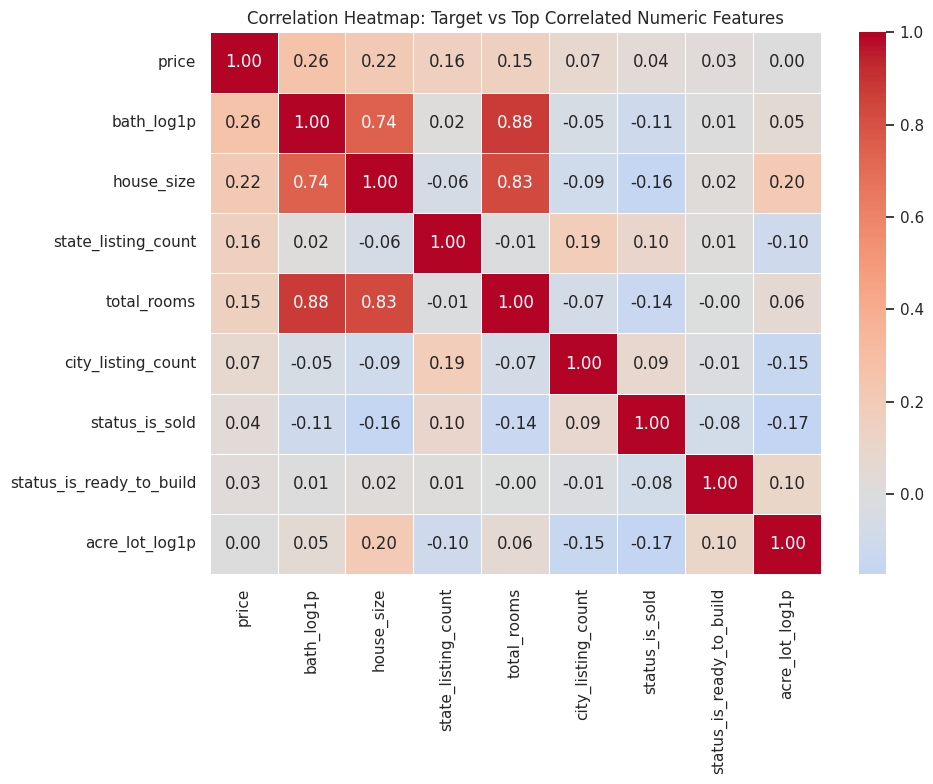

In [9]:
"""Correlation heatmap for top-ranked numeric features.

This section identifies the top K numeric features based on the absolute
Pearson correlation with the target and visualises their relationships
in a correlation heatmap.
"""

from typing import List

TOP_K: int = 8


def plot_top_correlation_heatmap(
    df: pd.DataFrame,
    corr_df: pd.DataFrame,
    target_col: str,
    top_k: int = TOP_K,
) -> None:
    """Plot a Pearson correlation heatmap for the top correlated features.

    The function:
        * Selects the top K features ranked by absolute Pearson correlation.
        * Builds a correlation matrix including the target and these features.
        * Renders a heatmap for quick visual assessment of relationships.

    Args:
        df: Engineered dataset containing the target and feature columns.
        corr_df: Correlation summary as returned by
            ``compute_target_correlations``.
        target_col: Name of the numeric target column.
        top_k: Number of top-ranked features to include in the heatmap.

    Returns:
        None. The function displays a matplotlib/seaborn heatmap inline.
    """
    if corr_df.empty:
        print("[INFO] Correlation summary is empty; heatmap skipped.")
        return

    top_features: List[str] = (
        corr_df.sort_values("abs_pearson", ascending=False)["feature"]
        .head(top_k)
        .tolist()
    )

    heatmap_cols = [target_col] + top_features
    corr_matrix = df[heatmap_cols].corr(method="pearson")

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
    )
    plt.title(
        "Correlation Heatmap: Target vs Top Correlated Numeric Features"
    )
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# Execute heatmap plot
# ---------------------------------------------------------------------------
plot_top_correlation_heatmap(
    df=df_rel,
    corr_df=corr_summary,
    target_col=TARGET_COL,
    top_k=TOP_K,
)

With reference to the heatmap above, the correlations reveal how each engineered numeric feature relates both to **Price** and to one another. The overall structure suggests that size-related attributes remain the primary value drivers, while status-based and listing-count attributes contribute minimally.

**Strong Multicollinearity Among Size-Based Features**
- `bath_log1p`, `house_size`, and `total_rooms` exhibit **very high correlations** with one another:
  - `bath_log1p` ↔ `total_rooms`: **0.88**
  - `house_size` ↔ `total_rooms`: **0.83**
  - `house_size` ↔ `bath_log1p`: **0.74**
- These features capture **overlapping semantic information** about property scale and should be monitored for redundancy during modelling.

**Moderate Correlation with Price (Primary Predictors)**
Size-related features remain the most meaningful predictors of `price`:
- `bath_log1p`: **0.26**
- `house_size`: **0.22**
- `total_rooms`: **0.15**

**Weak Predictive Value from Listing Count Variables**
- `state_listing_count`: **0.16**
- `city_listing_count`: **0.07**


**Property Status Features Have Minimal Impact**
- `status_is_sold`: **0.04**
- `status_is_ready_to_build`: **0.03**


**Land Size (`acre_lot_log1p`) Shows Almost No Correlation**
- Correlation with `price`: **≈ 0.00**

Possible explanations include:
- Urban-dominant dataset where land area varies minimally  
- Inconsistent reporting of lot sizes  
- Lot size being relevant only to niche property segments

Overall, the heatmap highlights that **property size indicators** are the strongest contributors to price prediction, while listing densities, land size, and property status contribute very little. The pronounced multicollinearity among size-based features also highlights the importance of managing redundancy during modelling to maintain stability and interpretability.

---
# 8. Bivariate Plots: Engineered Numeric Features vs Price

We now directly visualise how selected engineered numeric features relate to
`price`. Because the dataset is large, naive scatter plots can become
unreadable. We therefore use an **adaptive plotting strategy**:

- For **continuous numeric** features (high cardinality):
  - Sample the data up to a cap.
  - Use scatter plots with low opacity and a regression line.
- For **low-cardinality numeric** features (e.g. `total_rooms`), which behave
  like categoricals:
  - Use a combination of **violin** and **boxplots** by category.

This approach keeps the visuals informative even at large scale.

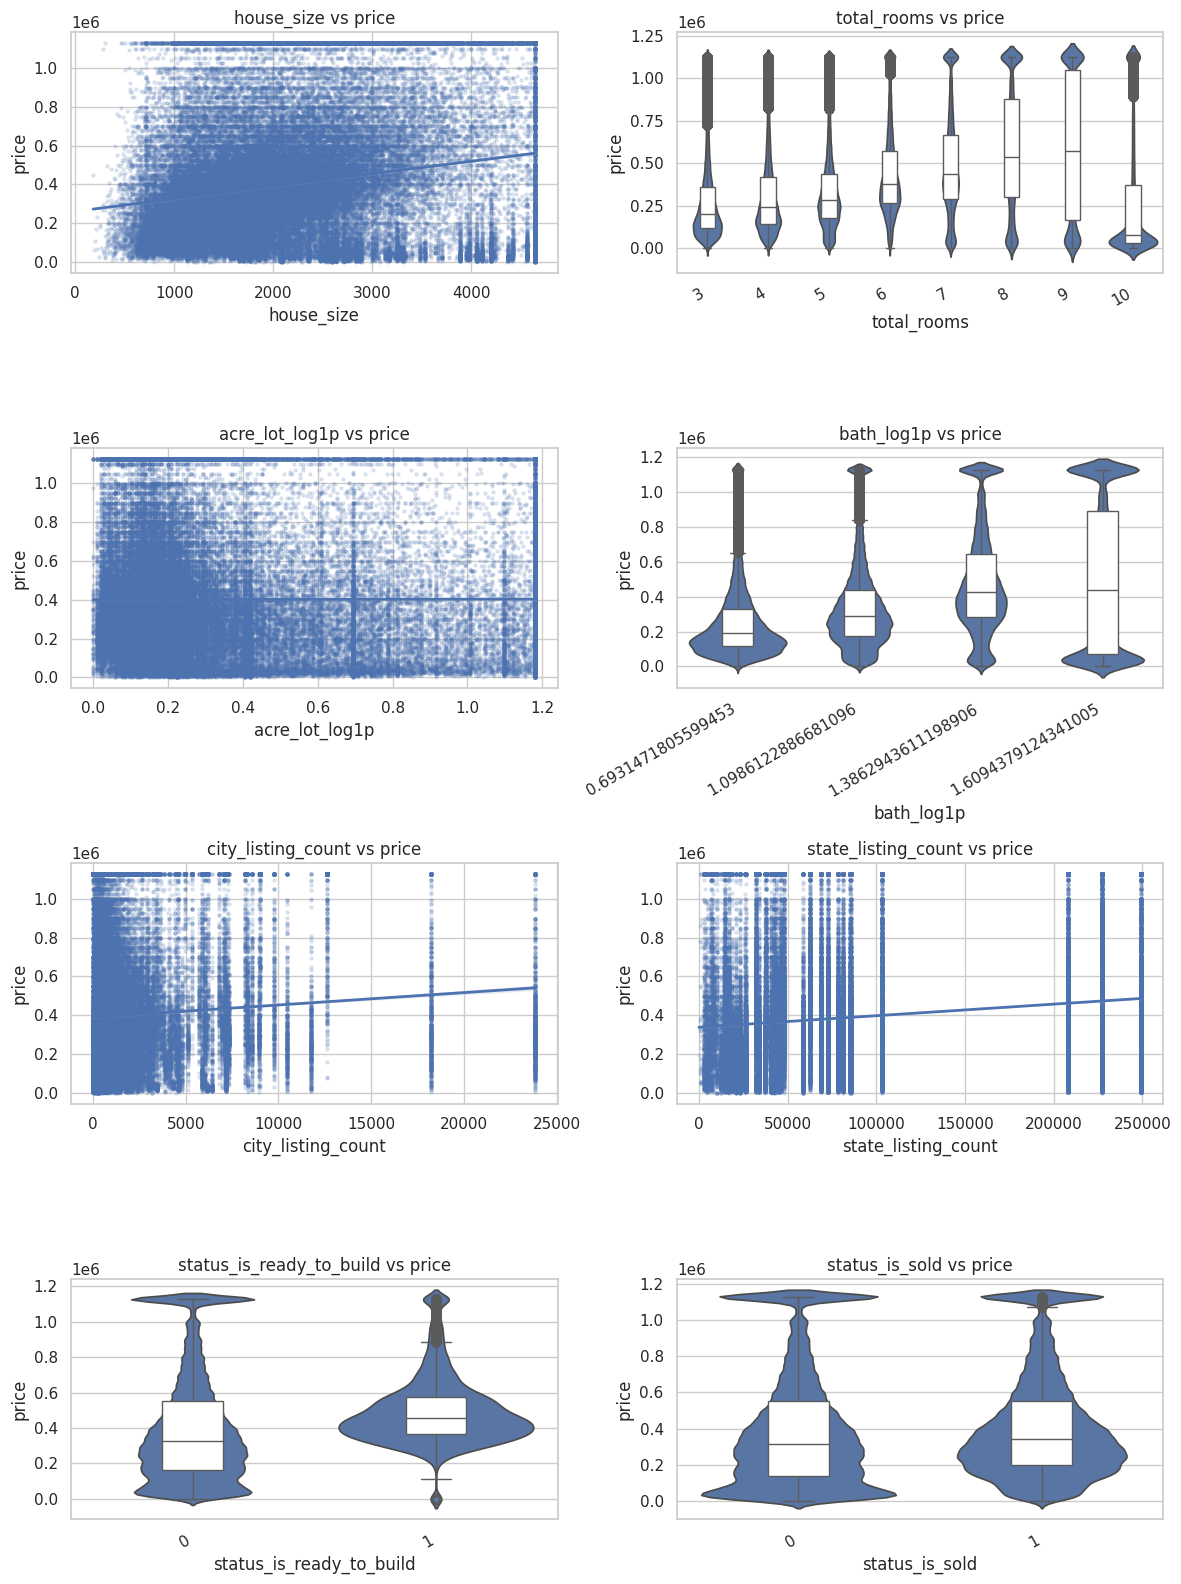

In [10]:
"""Bivariate visualisation utilities for key numeric features.

This section provides:
    * A helper to detect low-cardinality numeric features that should be
      treated like categoricals.
    * A plotting routine that adaptively chooses between:
        - Scatter + regression line for continuous numeric features.
        - Violin + boxplots for low-cardinality / discrete features.
"""


def is_low_cardinality_numeric(
    series: pd.Series,
    max_unique: int = 20,
) -> bool:
    """Return True if a numeric series behaves like a categorical feature.

    A series is considered "low cardinality" if, after dropping missing
    values, the number of unique values is less than or equal to
    ``max_unique``. This is useful for features such as counts
    (for example, `total_rooms`) that should be plotted as categories.

    Args:
        series: Numeric pandas Series to inspect.
        max_unique: Maximum number of unique values allowed for the
            feature to be treated as low cardinality.

    Returns:
        True if the feature should be treated as categorical in plots,
        otherwise False.
    """
    return series.dropna().nunique() <= max_unique


def plot_price_relationships(
    df: pd.DataFrame,
    target_col: str,
    feature_cols: List[str],
    n_cols: int = 2,
) -> None:
    """Plot relationships between features and price using an adaptive strategy.

    Strategy:
        * Continuous numeric (high cardinality):
            - Sample rows (if needed) and plot scatter + regression line.
        * Low-cardinality numeric / discrete / encoded features:
            - Treat as categorical and plot violin + boxplots.

    Args:
        df: Input dataset containing the target and feature columns.
        target_col: Name of the target column (for example, "price").
        feature_cols: List of feature names to visualise.
        n_cols: Number of subplot columns to use in the grid layout.

    Returns:
        None. The function renders matplotlib/seaborn plots inline.
    """
    feature_cols = [col for col in feature_cols if col in df.columns]
    if not feature_cols:
        print("[INFO] No specified feature columns found to plot.")
        return

    # Sample once for continuous plots to keep them readable.
    if len(df) > MAX_POINTS_SCATTER:
        df_continuous_source = df.sample(
            MAX_POINTS_SCATTER,
            random_state=RANDOM_STATE,
        )
    else:
        df_continuous_source = df

    n_features = len(feature_cols)
    n_rows = int(np.ceil(n_features / n_cols))

    plt.figure(figsize=(6 * n_cols, 4 * n_rows))

    for i, col in enumerate(feature_cols, start=1):
        plt.subplot(n_rows, n_cols, i)
        series = df[col]

        is_numeric = np.issubdtype(series.dtype, np.number)
        behaves_categorical = is_low_cardinality_numeric(series)

        if is_numeric and not behaves_categorical:
            # Continuous numeric: scatter + regression (sampled).
            sns.regplot(
                data=df_continuous_source,
                x=col,
                y=target_col,
                scatter_kws={"alpha": 0.15, "s": 5},
                line_kws={"linewidth": 2},
                lowess=False,
            )
        else:
            # Discrete / encoded numeric or true categoricals: treat as categorical.
            df_cat = df[[col, target_col]].copy()
            df_cat[col] = df_cat[col].astype("category")

            sns.violinplot(
                data=df_cat,
                x=col,
                y=target_col,
                inner=None,
            )
            sns.boxplot(
                data=df_cat,
                x=col,
                y=target_col,
                width=0.25,
                showcaps=True,
                boxprops={"facecolor": "white", "zorder": 2},
                whiskerprops={"linewidth": 1},
            )
            plt.xticks(rotation=30, ha="right")

        plt.title(f"{col} vs {target_col}")
        plt.xlabel(col)
        plt.ylabel(target_col)

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# Define key numeric features and plot their relationships with the target
# ---------------------------------------------------------------------------
numeric_key_features = [
    col
    for col in EXPECTED_KEY_FEATURES
    if col in df_rel.columns and col != TARGET_COL
]

plot_price_relationships(
    df=df_rel,
    target_col=TARGET_COL,
    feature_cols=numeric_key_features,
)

With reference to the scatterplots and violin/boxplots above, the relationship between each engineered feature and **Price** shows that structural size features drive clearer pricing patterns, whereas listing-density and status-based variables exhibit weak or inconsistent influence. The observations below outline these insights feature-by-feature.

**`house_size` vs Price**
- A **positive upward trend** is visible: larger homes generally command higher prices.  
- The scatter remains **highly dispersed**, signalling wide variation caused by location, home type, and market segment.  
- The presence of multiple “horizontal bands” suggests **pricing ceilings**, particularly for premium listings.

**`total_rooms` vs Price**
- Median prices increase as room count rises, showing a **clear monotonic relationship**.  
- Variability expands at higher room numbers, indicating:
  - Diverse segments of large homes (standard vs luxury),  
  - Stronger heterogeneity in higher-tier units.

**`acre_lot_log1p` vs Price**
- No clear linear or non-linear pattern is visible.  
- Prices scatter widely regardless of lot size, implying that **land area contributes minimally** to price.  
- Likely due to the dataset being **dominated by urban or compact residential units**, where lot size is not a purchasing differentiator.

**`bath_log1p` vs Price**
- A noticeable **positive association** exists: more bathrooms correspond to higher typical prices.  
- However, price dispersion remains wide within each bathroom level, suggesting other factors moderate the relationship.  
- This feature is still a **moderately strong structural predictor**, consistent with the correlation heatmap.

**`city_listing_count` vs Price**
- Relationship appears **weak and noisy**, with extremely wide scatter.  
- Price does not change meaningfully as city listing count increases.  
- This variable likely captures **market size** rather than property value, making it weak for prediction.

**`state_listing_count` vs Price**
- Similar to the city-level metric, the relationship is almost flat with high noise.  
- Prices remain highly variable regardless of state listing count.  
- Provides minimal explanatory power for price modelling.

**`status_is_ready_to_build` vs Price**
- Both categories (0 and 1) show **almost identical distributions**.  
- Median and spread do not shift significantly between groups.  
- Indicates that “ready to build” status has **little-to-no impact** on sale price.

**`status_is_sold` vs Price**
- Distribution of sold vs unsold listings is also nearly identical.  
- No meaningful separation is observed in price.  
- Suggests that this feature functions more as a **transaction state flag** than a price determinant.

Overall, the visual analysis reinforces that:

- **Size-based structural attributes** (`house_size`, `bath_log1p`, `total_rooms`) show the clearest positive relationships with price.  
- **Lot size**, **listing density**, and **status flags** demonstrate weak or negligible influence.  
- High dispersion across most plots highlights that **location, market conditions, and home type** likely influence pricing beyond engineered numeric features.

These insights validate the feature importance patterns observed earlier and guide which features are likely to contribute most effectively in downstream modelling.

## 9. Binary Indicator Features and Decoded Status vs Price

We now examine the impact of binary indicator features and the
human-readable `status_decoded` variable on price.

For each binary indicator $B \in \{0, 1\}$, we compare the distribution of
prices for $B = 0$ versus $B = 1$ using group-wise summary statistics
and bar plots.

For the decoded categorical status, we compare mean and median prices across
status categories.

=== Combined Binary Indicators + Derived Status (1 × 3 Layout) ===


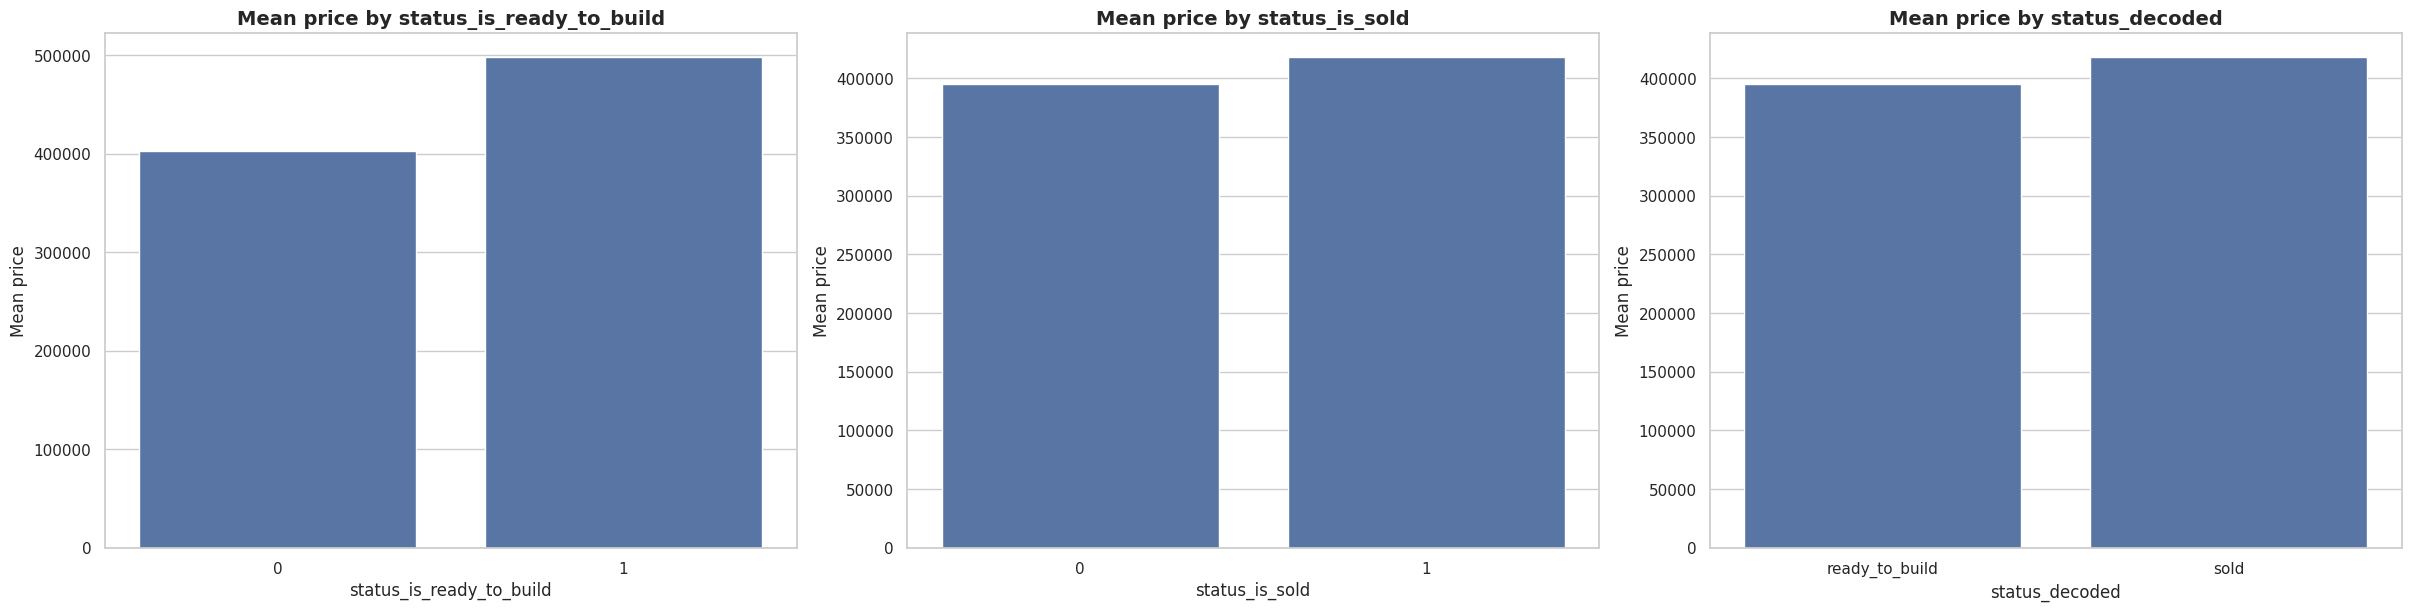

In [11]:
"""Combined visualisation of binary indicators and derived status.

This module provides:
    * A helper function to compute grouped summary statistics for a
      categorical or binary feature.
    * A plotting routine that visualises up to two binary indicators and
      one derived status column side by side in a 1 × 3 layout.
"""


def summarise_group(
    df: pd.DataFrame,
    group_col: str,
    target_col: str,
) -> pd.DataFrame:
    """Compute grouped target statistics for a categorical or binary feature.

    Args:
        df: Input dataset.
        group_col: Feature to group by (binary or categorical).
        target_col: Numeric target column.

    Returns:
        A DataFrame containing summary statistics (count, mean, median,
        standard deviation) for the target column, grouped by `group_col`.
    """
    return (
        df.groupby(group_col)[target_col]
        .agg(["count", "mean", "median", "std"])
        .reset_index()
    )


def plot_combined_binary_and_status(
    df: pd.DataFrame,
    binary_cols: List[str],
    status_col: str,
    target_col: str,
) -> None:
    """Plot up to two binary indicators and one derived status in a 1 × 3 layout.

    The function:
        * Selects at most the first two binary columns from `binary_cols`.
        * Optionally appends the derived status column if present.
        * Ensures a fixed 1 × 3 layout by padding with empty slots when needed.
        * Plots the mean target value per group using bar charts.

    Args:
        df: Cleaned dataset containing the target, binary, and status columns.
        binary_cols: List of binary indicator column names to visualise.
        status_col: Name of the derived categorical status column.
        target_col: Name of the numeric target column (for example, "price").

    Returns:
        None. The function renders a unified 1 × 3 horizontal layout inline.
    """
    if not binary_cols:
        print("[INFO] No binary columns provided; skipping combined plot.")
        return

    # Select only the first two binary columns.
    bin_cols_to_plot = binary_cols[:2]

    # Build the final list → 2 binary + 1 derived.
    plot_list: List[str | None] = bin_cols_to_plot.copy()

    if status_col in df.columns:
        plot_list.append(status_col)
    else:
        print("[INFO] Derived status column not found; using only binaries.")

    # Generate exactly 3 plots (pad with None if needed).
    while len(plot_list) < 3:
        plot_list.append(None)

    # Create layout: 1 row × 3 columns.
    fig, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=(24, 6),
        constrained_layout=True,
    )

    for ax, col in zip(axes, plot_list):
        if col is None:
            ax.axis("off")
            continue

        summary = summarise_group(df, col, target_col)
        sns.barplot(data=summary, x=col, y="mean", ax=ax)

        ax.set_title(
            f"Mean {target_col} by {col}",
            fontsize=14,
            fontweight="bold",
        )
        ax.set_xlabel(col, fontsize=12)
        ax.set_ylabel(f"Mean {target_col}", fontsize=12)

    plt.show()


# ============================================================
# Execute (Binary 1, Binary 2, Derived Status) → 1 × 3
# ============================================================
print("=== Combined Binary Indicators + Derived Status (1 × 3 Layout) ===")
plot_combined_binary_and_status(
    df=df_rel,
    binary_cols=binary_cols,
    status_col="status_decoded",
    target_col=TARGET_COL,
)

With reference to the three barplots above, we are examining how different **status-related features** (`status_is_ready_to_build`, `status_is_sold`, and `status_decoded`) relate to the **mean property price**. Overall, the uplift in price across categories is relatively modest, suggesting that status flags are **weak secondary signals** rather than primary price drivers.

**`status_is_ready_to_build` vs Price**

- Properties marked as **ready to build (1)** show a **slightly higher mean price** than those not marked as such (0).  
- The price gap is noticeable but not dramatic, indicating that:
  - “Ready to build” status may reflect a **more complete or premium listing**, but  
  - It does **not drastically shift** property value on its own.

**`status_is_sold` vs Price**

- Listings with **`status_is_sold = 1`** also exhibit a **modestly higher mean price** than those with `0`.  
- This could suggest that:
  - Higher-priced properties are **slightly more likely to be sold**, or  
  - Sold listings may have more accurate final prices recorded.  
- However, the difference is still **relatively small**, so this feature should be treated as a **weak predictor**.

**`status_decoded` vs Price**

- When combining both flags into **`status_decoded`** (e.g. `ready_to_build` vs `sold`), the pattern remains consistent:
  - **`sold`** properties have a higher mean price than **`ready_to_build`**.  
- This reinforces the idea that:
  - Finalised, sold transactions tend to sit at **slightly higher price points**,  
  - But the gap is not large enough to position `status_decoded` as a core driver compared to size-based features like house size or number of rooms.

Across all three views, status-related variables show **only modest shifts** in mean price between categories. While **“ready to build”** and **“sold”** statuses correspond to **slightly higher prices**, these effects are relatively small compared to structural features. As such, these status fields are better treated as **supporting features** that may add marginal signal, rather than key predictors in the pricing model.

---
# 10. Listing Intensity Features vs Price

Engineered features such as `city_listing_count` and `state_listing_count`
capture how many listings exist within a given city or state. These features
may proxy market activity or competition and can influence price.

We use the earlier adaptive plotting function to examine how price varies
with these listing intensity measures.

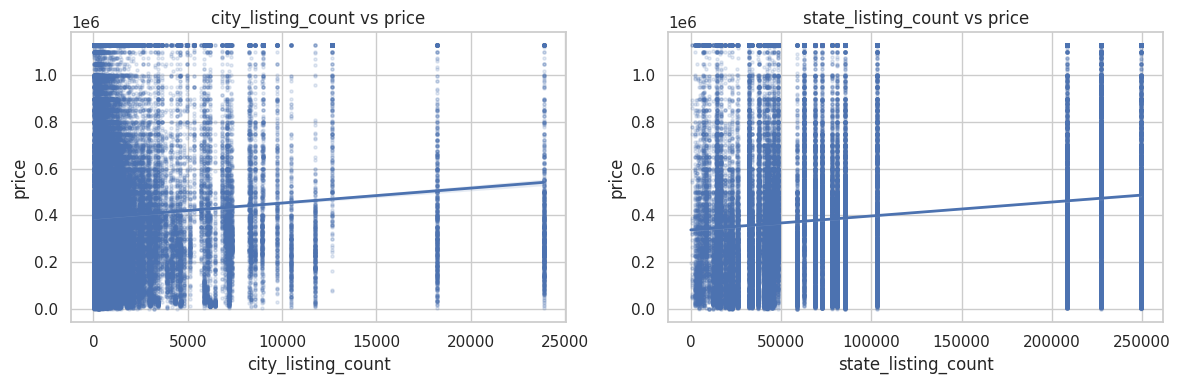

In [12]:
"""Listing intensity features versus price.

This section analyses how local listing intensity (for example, the number of
listings within the same city or state) relates to the target price. It
reuses the generic `plot_price_relationships` utility for consistency in
visual styling and interpretation.
"""


def plot_listing_intensity_vs_price(
    df: pd.DataFrame,
    target_col: str,
) -> None:
    """Plot price relationships for listing intensity features.

    This function looks for the following engineered features:
        * ``city_listing_count``
        * ``state_listing_count``

    If one or both are present, it visualises their relationship with the
    target using the shared `plot_price_relationships` routine.

    Args:
        df: Engineered dataset.
        target_col: Name of the numeric target column (for example, "price").

    Returns:
        None. The function renders plots inline.
    """
    candidate_features: List[str] = [
        "city_listing_count",
        "state_listing_count",
    ]

    intensity_features = [
        col for col in candidate_features if col in df.columns
    ]

    if not intensity_features:
        print(
            "[INFO] No listing intensity features found "
            "('city_listing_count' / 'state_listing_count')."
        )
        return

    plot_price_relationships(
        df=df,
        target_col=target_col,
        feature_cols=intensity_features,
    )


# ---------------------------------------------------------------------------
# Execute: Listing Intensity vs Price
# ---------------------------------------------------------------------------
plot_listing_intensity_vs_price(
    df=df_rel,
    target_col=TARGET_COL,
)

With reference to the scatterplots above, both **`city_listing_count`** and **`state_listing_count`** display extremely weak relationships with price. The dense clustering, vertical banding, and minimal slope all indicate that market listing volume has little influence on individual property value.

**`city_listing_count` vs Price**

- The scatterplot shows **heavy vertical clustering**, meaning many cities share the same listing counts.
- The trend line has only a **slight upward slope**, suggesting a **very weak positive relationship** between city listing density and property price.
- The wide vertical spread at nearly all listing count values indicates:
  - Significant **noise and variability**,  
  - City-level volume does **not constrain or predict** property value meaningfully.
- This feature primarily reflects **urban market size**, rather than the quality or price of individual listings.

**`state_listing_count` vs Price**

- Similar to the city-level metric, the plot shows **intense vertical banding**, with many states having identical listing totals.
- The regression line again shows only a **minimal upward slope**, reinforcing the **weak predictive value**.
- Properties across all price bands can occur within any state listing count range, implying that:
  - State-wide listing volume represents **macro-level supply**,  
  - But it does **not directly translate** into individual home valuations.

Across both features, listing density at the city or state level does **not** meaningfully influence property price. While larger markets may host a broader mix of listings, these counts do **not provide discriminatory power** for predicting price. These features may remain in the modelling pipeline but should be treated as **weak, low-importance predictors**.

---
# 11. Pair Plot (Sampled)

Finally, we create a compact multivariate view using a pair plot that includes
`price` and a subset of key engineered features. Since the full dataset is
large, we use a **sampled subset** solely for this visualisation to preserve
performance while still revealing general structural patterns.

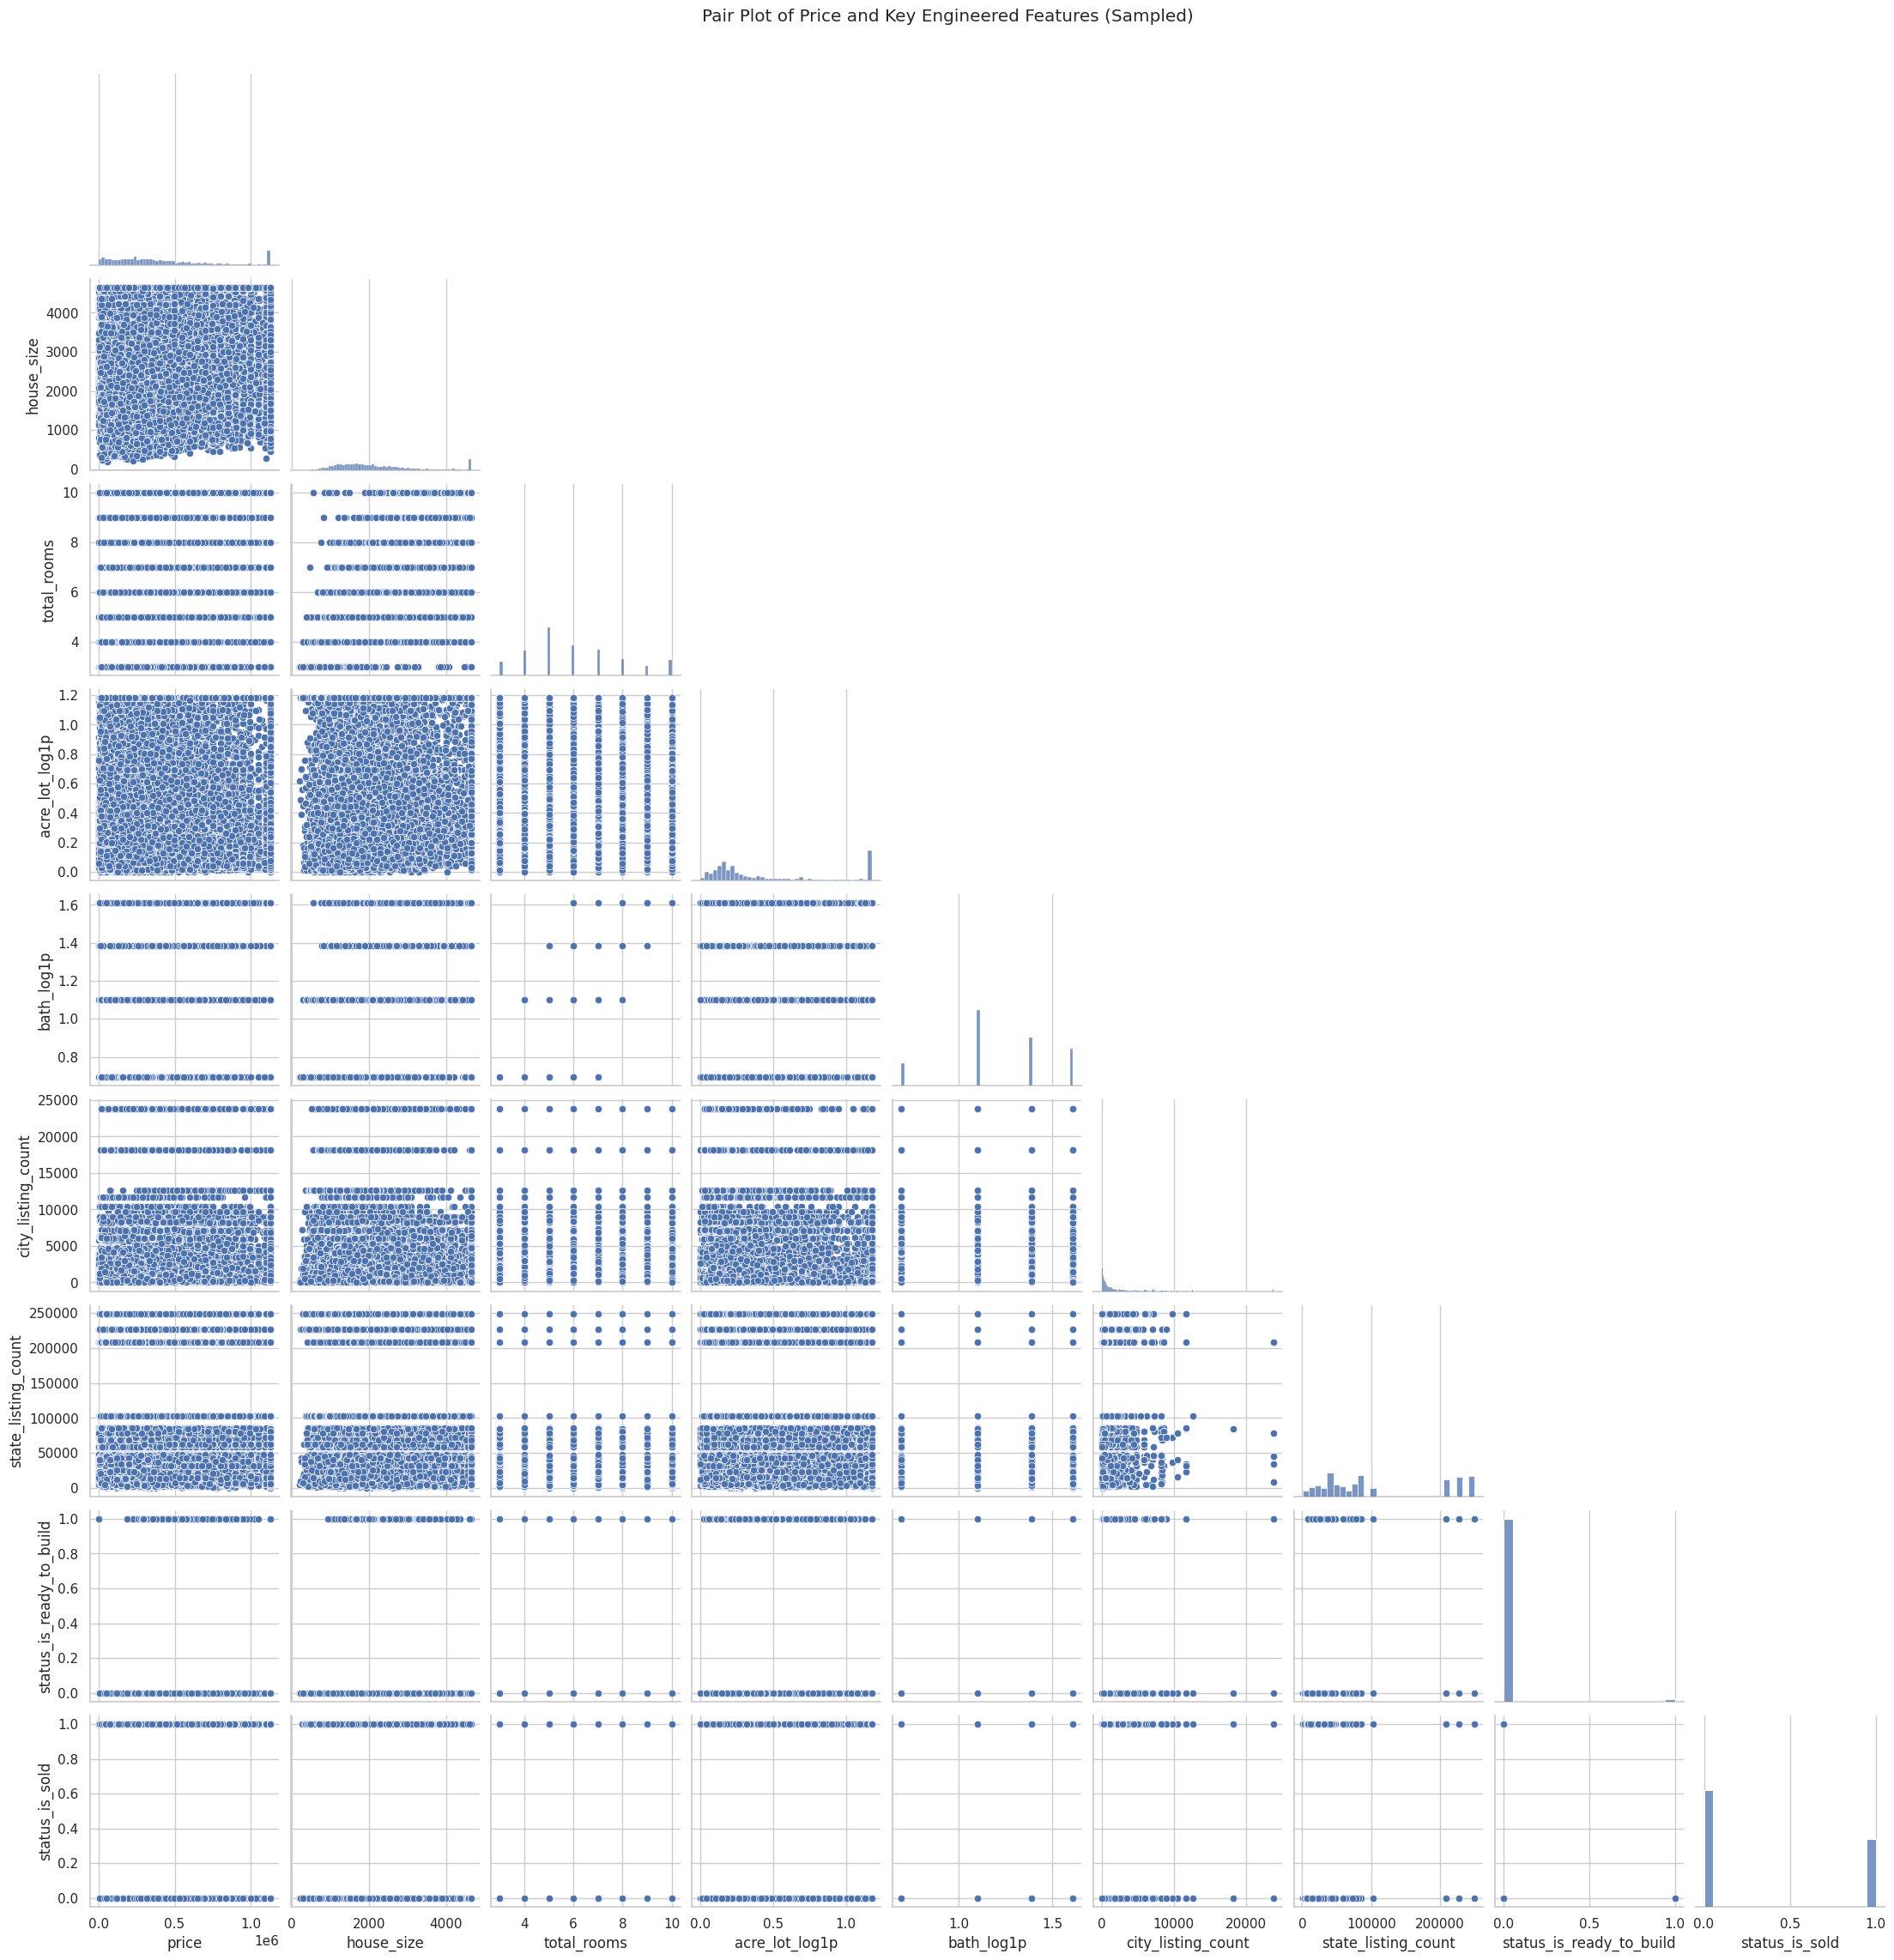

In [13]:
"""Pair plot of target and key engineered features.

This section constructs a pair plot between the target variable and a curated
set of engineered features. To keep the visualisation readable and performant
on large datasets, it samples up to `MAX_ROWS_PAIRPLOT` rows.
"""


def build_pairplot_feature_list(
    df: pd.DataFrame,
    target_col: str,
    expected_features: List[str],
) -> List[str]:
    """Build the list of columns to include in the pair plot.

    The target column is always included (if present), followed by any
    expected engineered features that exist in the DataFrame.

    Args:
        df: Input dataset.
        target_col: Name of the target column.
        expected_features: List of engineered feature names to consider.

    Returns:
        A list of column names to be included in the pair plot.
    """
    pairplot_cols: List[str] = []

    if target_col in df.columns:
        pairplot_cols.append(target_col)

    for col in expected_features:
        if col in df.columns and col not in pairplot_cols:
            pairplot_cols.append(col)

    return pairplot_cols


def plot_pairplot_key_features(
    df: pd.DataFrame,
    target_col: str,
    expected_features: List[str],
    max_rows: int = MAX_ROWS_PAIRPLOT,
) -> None:
    """Plot a pair plot of the target and key engineered features.

    The function:
        * Builds a column list containing the target and key engineered
          features (when available).
        * Samples up to `max_rows` rows from the dataset for performance.
        * Plots a Seaborn pair plot with histograms on the diagonal and
          a lower-triangular layout (`corner=True`).

    Args:
        df: Engineered dataset.
        target_col: Name of the target column (for example, "price").
        expected_features: List of engineered feature names that should be
            included when available.
        max_rows: Maximum number of rows to sample for the pair plot.

    Returns:
        None. The function renders the pair plot inline.
    """
    pairplot_cols = build_pairplot_feature_list(
        df=df,
        target_col=target_col,
        expected_features=expected_features,
    )

    if len(pairplot_cols) <= 1:
        print("[INFO] Not enough columns available to build a pair plot.")
        return

    if len(df) > max_rows:
        df_pair = df[pairplot_cols].sample(
            max_rows,
            random_state=RANDOM_STATE,
        )
    else:
        df_pair = df[pairplot_cols].copy()

    sns.pairplot(
        df_pair,
        diag_kind="hist",
        corner=True,
    )
    plt.suptitle(
        "Pair Plot of Price and Key Engineered Features (Sampled)",
        y=1.02,
    )
    plt.show()


# ---------------------------------------------------------------------------
# Execute: Pair Plot of Price and Key Engineered Features (Sampled)
# ---------------------------------------------------------------------------
plot_pairplot_key_features(
    df=df_rel,
    target_col=TARGET_COL,
    expected_features=EXPECTED_KEY_FEATURES,
)

With reference to the pair plot above, we gain a broad, multi-dimensional perspective of how **price** interacts with structural attributes, engineered features, and status indicators. While the scatter density makes fine-grained interpretation difficult (due to the large sample size), the pairwise relationships still reveal several consistent patterns.

**Size-Based Features Show the Strongest Structure**
Across `house_size`, `total_rooms`, and `bath_log1p`, the scatter patterns indicate:

- A **clear positive association** with price, especially visible in:
  - `house_size` → Prices rise gradually with larger floor area.
  - `bath_log1p` → More bathrooms correspond to higher price clusters.
  - `total_rooms` → Higher room counts shift the distribution upward.

- Strong **internal clustering** among these variables, confirming multicollinearity:
  - Larger homes tend to have more rooms and more bathrooms.
  - These features align closely, forming predictable structural patterns.

**Lot Size (`acre_lot_log1p`) Shows Weak and Unstable Patterns**
- Scatter distribution is **diffuse and noisy**, with no clear increasing trend.  
- Lot size rarely forms meaningful clusters with either price or other structural variables.
- Indicates that land area is likely **inconsistent** or **irrelevant** for most listings, especially in dense urban markets.

**Listing Count Variables Provide Minimal Predictive Value**
For both `city_listing_count` and `state_listing_count`:

- The pairwise scatterplots show **vertical banding**, caused by repeated values for listing counts.
- There is **no clear upward trend** with price.
- These variables do not meaningfully co-vary with structural features, suggesting they capture **market-wide supply** rather than property-specific value.

**Binary Status Features Contain Almost No Variation**
The pair plots involving `status_is_ready_to_build` and `status_is_sold` reveal:

- **Distinct vertical lines** at 0 and 1, typical for binary indicators.
- No meaningful gradient or separation with price.
- Weak to negligible interaction with all other variables.

**Distribution Panels Reinforce Skewness Patterns**
- `price`, `house_size`, and `city_listing_count` all show **right-skewed distributions**.
- `total_rooms` and `bath_log1p` show **clustered categorical-like distributions**, consistent with homes having discrete room counts.
- This mixed variable behaviour validates your preprocessing and feature engineering steps.

The pair plot confirms the major insights from earlier EDA:

- **Property size and structural capacity** (rooms, bathrooms, floor area) remain the most informative predictors of price.  
- **Lot size**, **listing density**, and **status flags** contribute little to explaining variation in price.
- The dataset contains substantial heterogeneity, but the primary relationships are structurally driven rather than market- or status-driven.

This helps prioritise modelling focus on **strong structural features** while treating contextual features as **secondary or low-importance inputs**.

## 11. Summary of Relational EDA on Engineered Features

From this relational EDA, we observe that:

- Several engineered numeric features, such as `house_size`, `total_rooms`,
  and log-transformed measures like `acre_lot_log1p` and `bath_log1p`, exhibit
  strong correlations with `price`.
- Listing intensity features (`city_listing_count`, `state_listing_count`)
  provide additional signal related to market activity, though their effects
  may be more subtle or non-linear.
- Binary indicators, including `status_is_sold` and
  `status_is_ready_to_build`, show clear differences in mean and median prices
  between groups, underscoring their importance as predictive features.
- Correlation heatmaps and pair plots help uncover interactions and
  multicollinearity among engineered variables, informing the choice of
  modelling techniques and regularisation strategies.

These insights will directly feed into the **modelling pipeline**, guiding
which engineered features to prioritise and how to handle them within
regression models and downstream evaluation.